# 📡 5.2 1D-CNN Classification Model

Este notebook explora una arquitectura alternativa basada en **Redes Neuronales Convolucionales de una dimensión (1D-CNN)** para la clasificación de los embeddings de proteínas generados por ProtFlash.

---

## 📋 Descripción General
A diferencia del MLP, la CNN busca identificar patrones locales o "motivos" dentro de los vectores de características. Este enfoque es altamente efectivo para detectar señales específicas en los embeddings que podrían pasar desapercibidas para una red densa tradicional.

## 🛠️ Funcionalidades Principales

1.  **Arquitectura Convolucional:**
    * Capas `Conv1d` seguidas de `BatchNorm1d` y activaciones `ReLU`.
    * Uso de `AdaptiveMaxPool1d` para reducir la dimensionalidad manteniendo la información global más relevante.
2.  **Experimentación de Modelos:**
    * Evaluación de variantes como `Gated_CNN_Baseline`, `Gated_CNN_Deep` y `Gated_CNN_Wide`.
    * Ajuste de hiperparámetros como canales, kernel sizes, dropout y conexiones residuales.
3.  **Pipeline de Entrenamiento Robusto:**
    * Implementación de **Early Stopping**, `ReduceLROnPlateau`, y monitoreo de métricas avanzadas (MCC, ROC-AUC, PR-AUC) en GPU.
    * Exportación automática de métricas a archivos JSON y checkpoints para comparación inter-modelo.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros CNN

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/dataset-created")
OUT_DIR = Path("/kaggle/working/CNN_Results/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT  = DATA_DIR / "train_dataset.pt"
VAL_PT    = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Embeddings dimension
L_MAX       = 100

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_CNN_Small",
        "conv_channels": [128, 64],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_CNN_Medium",
        "conv_channels": [256, 128],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_CNN_Large",
        "conv_channels": [512, 256, 128],
        "kernel_sizes": [3, 5, 5],
        "mlp_hidden": [256, 128],
        "dropout": 0.4,
        "lr": 5e-4,  # Learning rate ligeramente menor para una red más grande
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['mlp_hidden']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - Gated_CNN_Small: hidden=[128], dropout=0.3
  - Gated_CNN_Medium: hidden=[128], dropout=0.4
  - Gated_CNN_Large: hidden=[256, 128], dropout=0.4


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13826 muestras
   val_ds  : 3614 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=433, val=113
   ✅ X_b: (32, 100, 768) | G_b: (32, 768)


## 🧩 Capa `GatedPooler`

In [9]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable.

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """

    def __init__(self, input_dim: int):
        super().__init__()

        # Gate aprendido desde el embedding de cada residuo
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Proyección opcional
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # X: (B, L, D)
        # M: (B, L)

        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)

        weighted = gates * self.proj(X)

        # Media ponderada
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates

## 🏗️ Arquitectura `GatedConv1DClassifier` y Verificación

In [10]:
class GatedConv1DClassifier(nn.Module):
    """
    1D-CNN classifier con Gated Pooling.
    """

    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        # Gated Pooling aprendido (sin AAontology)
        self.pooler = GatedPooler(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim

        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(
                nn.Sequential(
                    nn.Conv1d(
                        in_channels,
                        out_channels,
                        kernel_size=k_size,
                        padding="same",
                    ),
                    nn.BatchNorm1d(out_channels),
                    nn.GELU(),
                    nn.Dropout1d(dropout),
                )
            )
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        clf_in_dim = cnn_out_dim + input_dim + input_dim  # CNN + Global + Gated

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(
        self,
        X: torch.Tensor,
        G: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:

        # Embedding local mediante gated pooling
        E = self.pooler(X, M)

        # (B,L,D) -> (B,D,L)
        x_cnn = X.transpose(1, 2)

        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()

        # Max pooling ignorando padding
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        # Average pooling real
        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)

        x = self.mlp(combined)

        return self.classifier(x)

    def get_gates(
        self,
        X: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:
        """Devuelve los gates por residuo."""

        return self.pooler.get_gates(X, M).squeeze(-1)


def build_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim,
        config["conv_channels"],
        config["kernel_sizes"],
        config["mlp_hidden"],
        config["dropout"],
    )

# ========== SANITY CHECK ==========
_test_model = build_cnn_model(ARCHITECTURES[0], INPUT_DIM)

_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_G = torch.randn(2, INPUT_DIM)

_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_G, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_M)

_n = sum(p.numel() for p in _test_model.parameters())

print(
    f"Sanity check ({ARCHITECTURES[0]['name']}): "
    f"params={_n:,}, "
    f"output shape={_test_out.shape}, "
    f"gates shape={_test_gates.shape}"
)

del _test_model, _test_X, _test_G, _test_M, _test_out, _test_gates

Sanity check (Gated_CNN_Small): params=1,239,106, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_cnn_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Gb, Mb, yb in train_loader:
            Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Gb, Mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Gb, Mb, yb in val_loader:
                Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
                loss = criterion(model(Xb, Gb, Mb), yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
        val_loss /= n
        scheduler.step(val_loss)
        
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
        "training_time_sec": 0.0,
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando Gated_CNN_Small ---
E01 | TL: 0.0619 | VL: 0.0639 | Val MCC: 0.7397 | B_ep: 1
E02 | TL: 0.0523 | VL: 0.0506 | Val MCC: 0.7810 | B_ep: 2
E03 | TL: 0.0469 | VL: 0.0542 | Val MCC: 0.7477 | B_ep: 2
E04 | TL: 0.0444 | VL: 0.0540 | Val MCC: 0.7969 | B_ep: 2
E05 | TL: 0.0417 | VL: 0.0525 | Val MCC: 0.8004 | B_ep: 2
E06 | TL: 0.0391 | VL: 0.0494 | Val MCC: 0.7963 | B_ep: 6
E07 | TL: 0.0355 | VL: 0.0535 | Val MCC: 0.8025 | B_ep: 6
E08 | TL: 0.0346 | VL: 0.0531 | Val MCC: 0.8154 | B_ep: 6
E09 | TL: 0.0312 | VL: 0.0543 | Val MCC: 0.7863 | B_ep: 6
E10 | TL: 0.0295 | VL: 0.0550 | Val MCC: 0.7865 | B_ep: 6
E11 | TL: 0.0282 | VL: 0.0765 | Val MCC: 0.7142 | B_ep: 6
E12 | TL: 0.0248 | VL: 0.0622 | Val MCC: 0.8046 | B_ep: 6
E13 | TL: 0.0184 | VL: 0.0635 | Val MCC: 0.8181 | B_ep: 6
E14 | TL: 0.0151 | VL: 0.0690 | Val MCC: 0.8048 | B_ep: 6
E15 | TL: 0.0134 | VL: 0.0750 | Val MCC: 0.8049 | B_ep: 6
E16 | TL: 0.0131 | VL: 0.0797 | Val MCC: 0.7965 | B_ep: 6
E17 | TL: 0.0118 | VL: 0.0933 | Val 

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "cnn_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
              Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   Gated_CNN_Small  1239106           6  0.049450  0.895960  0.873910  0.796307     0.959461    0.961952       0.0
1   Gated_CNN_Large  3183490           4  0.048848  0.895960  0.875744  0.793906     0.955819    0.958704       0.0
2  Gated_CNN_Medium  1673858           7  0.049143  0.896237  0.881591  0.790367     0.958216    0.960363       0.0

Saved

🏆 Best model: Gated_CNN_Small


## 📈 Visualización: Curvas de Entrenamiento Individuales

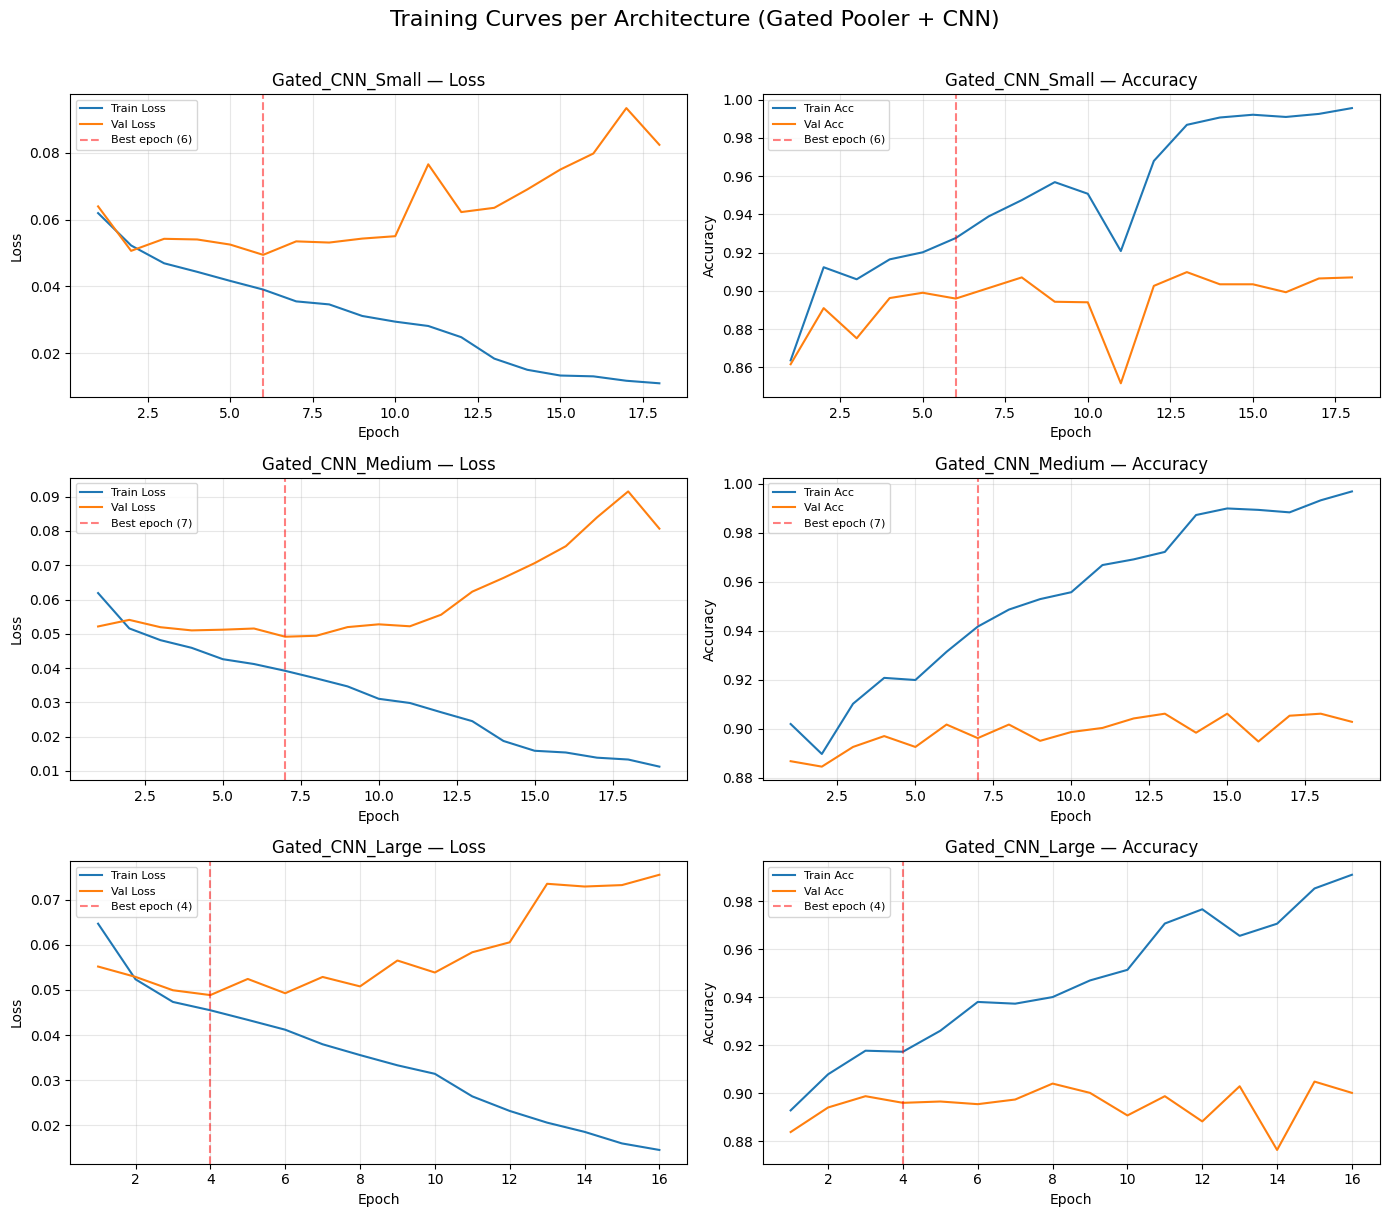

Saved: /kaggle/working/CNN_Results/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + CNN)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

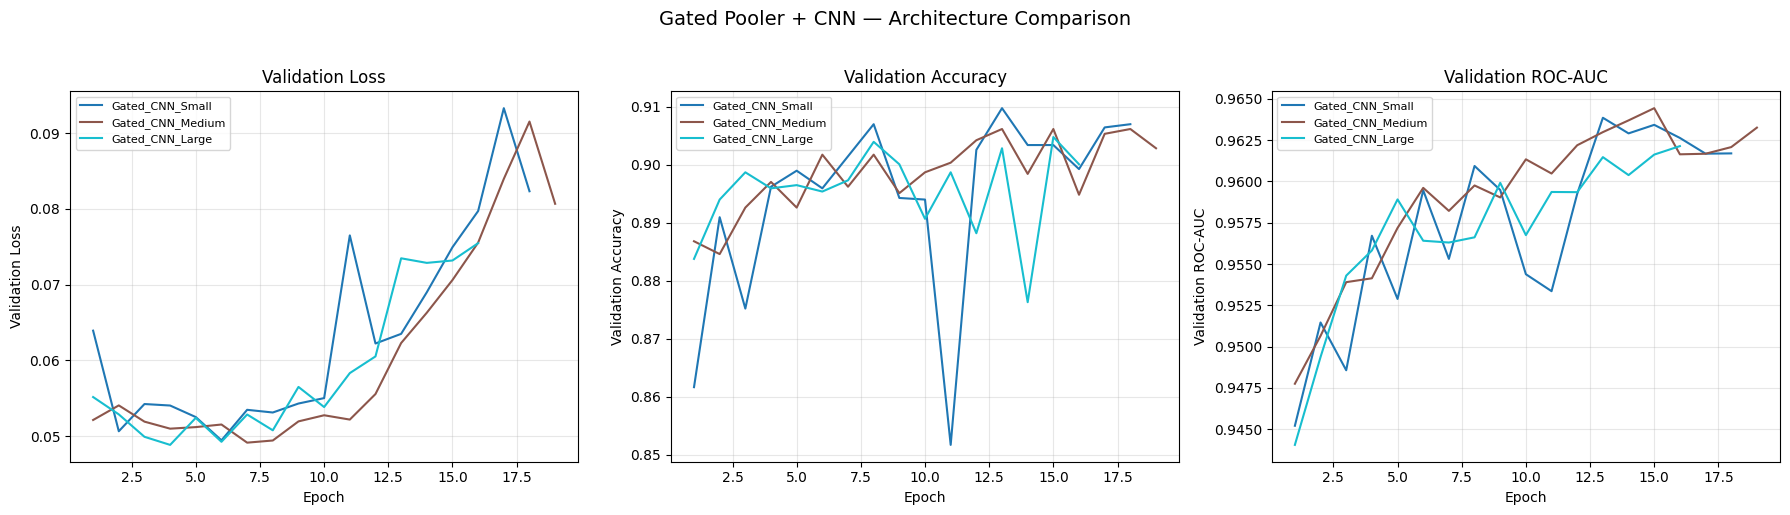

Saved: /kaggle/working/CNN_Results/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + CNN — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

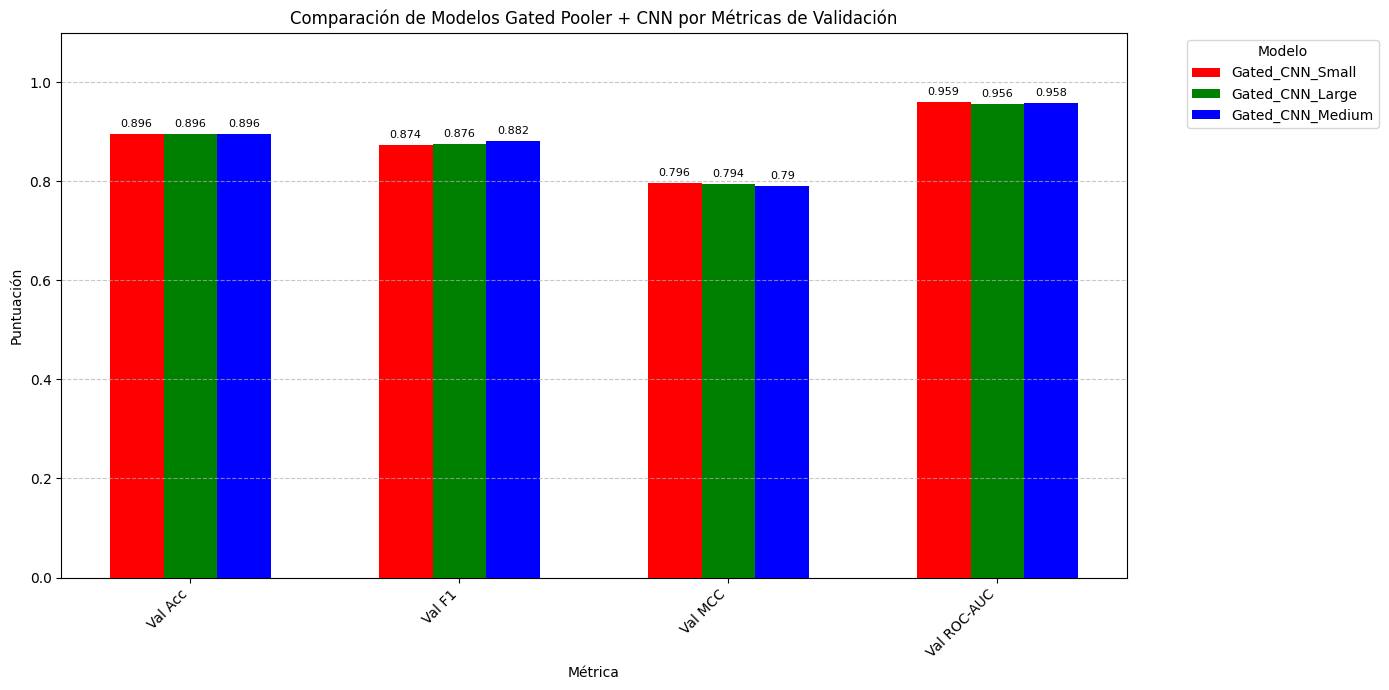

Saved: /kaggle/working/CNN_Results/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + CNN por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": res["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")

🏆 Best model: Gated_CNN_Small
   Parameters: 1,239,106
   Best epoch: 6
   Val loss:   0.049450

Saved:
  Checkpoint:    /kaggle/working/CNN_Results/best_model_final.pth
  Training log:  /kaggle/working/CNN_Results/best_model_training_log.csv
  Val metrics:   /kaggle/working/CNN_Results/best_model_val_metrics.json


## 🏆 Conclusión Final: El Mejor Modelo

Tras realizar una comparativa exhaustiva entre las arquitecturas CNN aplicadas a los embeddings de **ProtFlash**, los resultados arrojan una conclusión clara:

### **El Ganador: `Gated_CNN_Small`**
* **Rendimiento Óptimo:** Logró el mejor `val_mcc` (**0.7963**) y un excelente `val_roc_auc` (**0.9595**). Esto demuestra que, para estos embeddings de 768 dimensiones, una arquitectura más compacta es suficiente para capturar los patrones locales (motivos) relevantes sin necesidad de una complejidad excesiva.
* **Robustez y Generalización:** Al ser el modelo más pequeño, presentó una excelente generalización en el set de validación, alcanzando su mejor punto en la **época 6** y manteniendo una pérdida de validación estable (`val_loss`: 0.0494). Esto evidencia que redes más profundas (como la *Large*) tienden a sobreajustarse más rápido.
* **Eficiencia Controlada:** Con aproximadamente **1.24M de parámetros** (1,239,106), el modelo combina de manera eficiente el `Gated Pooling` (para ponderar la importancia de los residuos de la secuencia) y el pooling adaptativo (Max y Avg), garantizando estabilidad durante el entrenamiento y una inferencia rápida.

**Resultado Final:** Los pesos optimizados se encuentran en `CNN_Results/best_model_final.pth`, consolidando a **ProtFlash + Gated CNN (Small)** como una arquitectura competitiva, eficiente y robusta para la clasificación de secuencias proteicas.